# Causal Graphs and Causal Discovery

- This notebook teaches the foundations of causal graphs and causal discovery
  - How to encode domain knowledge as a DAG
  - How to learn causal structure from data using different algorithm families
  - How to validate and refute hypothesized causal graphs
- Learning objectives:
  - Specify causal graphs using domain knowledge
  - Compare three families of causal discovery algorithms (CDT, dodiscover,
    causal-learn)
  - Validate causal hypotheses using independence tests
  - Refute and stress-test discovered graphs

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Helpers imports.
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

# Notebook-specific utilities.
import dowhy_API_utils as dauti

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
hdbg.init_logger(verbosity=logging.INFO, use_exec_path=False)

_LOG.info("Notebook initialized")

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-e7c2e2d3-a92a-4de4-bd22-3fea26a6ad19.json'
INFO  Notebook initialized


# Cell 1: Introduction to causal graphs

- Causal graphs (DAGs) encode assumptions about how variables influence each
  other
    - A statistical model describes joint distributions
    - A causal model describes what happens under interventions
- The classic example: ice cream sales and drownings are correlated because
  temperature drives both
  - Statistical thinking sees a correlation
  - Causal thinking attributes both to a common cause and rejects the direct
    link

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

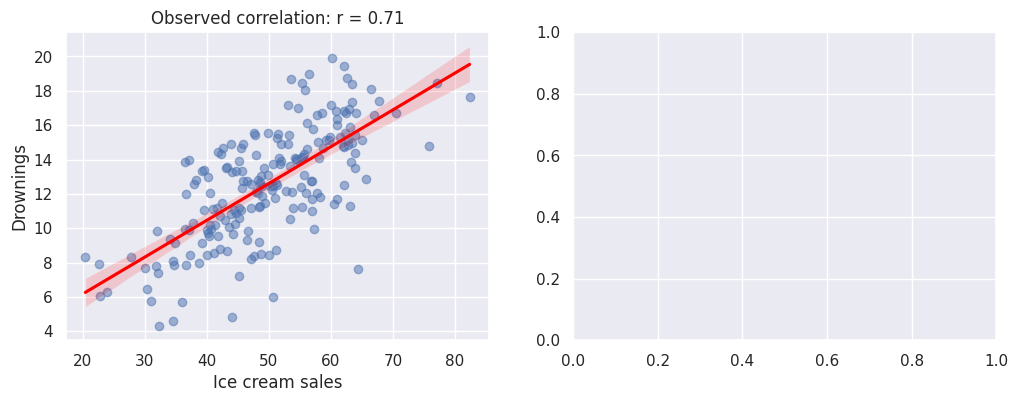

In [3]:
# Plot a correlation-vs-causation example with the implied DAG.
dauti.cell1_plot_correlation_vs_causation(figsize=(12, 4))

In [ ]:
# Build three motivating DAGs across health, economics, and social domains.
domain_dags = dauti.cell1_create_motivating_dags()

# Print the DAGs to show how they are made.
for domain_name, G in domain_dags.items():
    print(f"{domain_name} domain DAG edges:")
    for u, v in G.edges():
        print(f"  {u} -> {v}")
    print()

# The function cell1_plot_dag() plots a DAG with consistent styling and layout.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.tight_layout()
for ax, (name, G) in zip(axes, domain_dags.items()):
    ax.margins(0.2)
    dauti.cell1_plot_dag(G, name, ax=ax)
plt.show()
# Each domain encodes domain knowledge as a DAG that constrains plausible
# causal mechanisms.

In [ ]:
# Interactive widget: toggle edges to explore the space of DAGs.
# The widget shows all edges even when the graph is not a DAG, with proper layout margins.
dauti.cell1_interactive_edge_toggle(domain_dags["Health"])
# Toggling edges shows how each assumption changes the implied causal story.

# Cell 2: Domain knowledge and expert causal graphs

- In practice, experts encode their understanding as a DAG with explicit edges
- We simulate a healthcare dataset with a known DAG so we can later check
  whether discovery methods recover it
- Variables in the simulated dataset:
  - $\mathit{Age}$, $\mathit{Smoking}$, $\mathit{Exercise}$, $\mathit{Diet}$
  - $\mathit{Cholesterol}$, $\mathit{BloodPressure}$, $\mathit{HeartDisease}$

In [ ]:
# Generate the synthetic healthcare data.
df_health = dauti.cell2_generate_healthcare_data(n_samples=1000)

print(f"Generated {len(df_health)} samples with {df_health.shape[1]} variables")
df_health.head()

In [ ]:
# Build the expert DAG that captures the true data-generating process.
true_dag = dauti.cell2_build_domain_dag()

fig, ax = plt.subplots(figsize=(10, 7))
dauti.cell1_plot_dag(true_dag, "Expert-specified healthcare DAG", ax=ax)
plt.show()

In [ ]:
# Print the graph structure as an edge list table for inspection.
dauti.cell2_describe_graph(true_dag)

# Cell 3: Limitations of domain knowledge alone

- Domain experts may disagree about edge directions or which edges exist
- The data can help adjudicate by checking which candidate graph best matches
  the observed conditional independencies
- We compare three candidate hypotheses on the subset
  $\{Exercise, Diet, Cholesterol, BloodPressure\}$ and score each against data

In [ ]:
# Build candidate hypothesis graphs and score them against the data.
candidates = dauti.cell3_make_candidate_graphs()
sub_df = pd.DataFrame(df_health[["Exercise", "Diet", "Cholesterol", "BloodPressure"]])
scores = {
    name: dauti.cell3_score_graph_against_data(G, sub_df)
    for name, G in candidates.items()
}

scores_df = pd.DataFrame(
    [
        {"Hypothesis": name, "Mean p-value at non-edges": score}
        for name, score in scores.items()
    ]
)
print(scores_df)

In [ ]:
# Interactive widget: pick a hypothesis and inspect its data-consistency score.
dauti.cell3_interactive_hypothesis_comparison(sub_df, candidates)
# Higher scores mean the data is more consistent with the graph's implied
# conditional independencies.

# Cell 4: Causal discovery algorithms overview

- Three main library families dominate practical causal discovery
  - **CDT** (Causal Discovery Toolbox): score-based and hybrid methods
  - **dodiscover**: PyWhy's constraint-based discovery framework
  - **causal-learn**: a broad library covering PC, FCI, GES, LiNGAM
- All approaches share a common workflow: data $\to$ independence tests $\to$
  skeleton $\to$ orientation rules $\to$ causal graph
- They differ in assumptions, computational complexity, and output type

In [ ]:
# Show the comparison table of algorithm families.
dauti.cell4_algorithm_comparison_table()

In [ ]:
# Visualize the canonical causal discovery workflow.
dauti.cell4_plot_workflow_diagram(figsize=(10, 3))

# Cell 5: Causal discovery with CDT

- CDT focuses on score-based pipelines that learn skeletons then orient edges
- The simplified CDT-style discovery here:
  - Builds the skeleton using partial correlation tests at increasing
    conditioning set sizes
  - Orients each edge using a provided topological ordering
- We compare the discovered DAG to the true expert DAG using precision,
  recall, and F1

In [ ]:
# Run a CDT-style discovery on the healthcare data.
variable_order = [
    "Age",
    "Smoking",
    "Exercise",
    "Diet",
    "Cholesterol",
    "BloodPressure",
    "HeartDisease",
]
cdt_dag = dauti.cell5_run_cdt_like_discovery(
    df_health,
    alpha=0.05,
    variable_order=variable_order,
)

In [ ]:
# Compare the discovered DAG to ground truth.
cdt_metrics = dauti.cell5_compute_graph_metrics(true_dag, cdt_dag)

print("CDT-style discovery vs ground truth:")
for k, v in cdt_metrics.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

In [ ]:
# Visualize the side-by-side comparison.
dauti.cell5_plot_discovery_comparison(true_dag, cdt_dag, figsize=(14, 5))
# Green edges are correctly recovered; red edges are spurious.

# Cell 6: Causal discovery with dodiscover

- dodiscover follows the constraint-based PC family
- The simplified dodiscover-style discovery here:
  - Builds the skeleton via conditional independence tests
  - Records separating sets for non-adjacent pairs
  - Orients v-structures using the rule: if $A - B - C$ are unshielded and $B$
    is not in the separating set of $A$ and $C$, then $A \to B \leftarrow C$

In [ ]:
# Run a dodiscover-style PC procedure.
dodiscover_dag = dauti.cell6_run_dodiscover_like(df_health, alpha=0.05)

dodiscover_metrics = dauti.cell5_compute_graph_metrics(true_dag, dodiscover_dag)

print("dodiscover-style discovery vs ground truth:")
for k, v in dodiscover_metrics.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

In [ ]:
# Side-by-side comparison and agreement table with CDT.
agreement_cdt_dodiscover = dauti.cell6_plot_method_comparison(
    cdt_dag,
    dodiscover_dag,
    labels=("CDT-style", "dodiscover-style"),
    figsize=(14, 5),
)
print(agreement_cdt_dodiscover)

# Cell 7: Causal discovery with causal-learn

- causal-learn provides several algorithm flavors:
  - **PC**: constraint-based, returns a CPDAG
  - **GES**: greedy equivalence search, score-based
  - **FCI**: handles potential latent confounders, returns a PAG
- We expose all three through a single interactive widget so students can
  compare the resulting graphs

In [ ]:
# Run PC, GES, and FCI style discovery procedures.
pc_dag = dauti.cell7_run_pc_algorithm(df_health, alpha=0.05)
ges_dag = dauti.cell7_run_ges_algorithm(df_health, variable_order=variable_order)
fci_dag = dauti.cell7_run_fci_algorithm(df_health, alpha=0.05)

print("Edges discovered:")
print(f"  PC: {len(pc_dag.edges())}")
print(f"  GES: {len(ges_dag.edges())}")
print(f"  FCI: {len(fci_dag.edges())}")

In [ ]:
# Interactive widget to switch among causal-learn algorithms.
dauti.cell7_interactive_causal_learn_widget(
    df_health,
    variable_order=variable_order,
)

# Cell 8: Comparing causal discovery methods

- With three discovered graphs, we can ask:
  - Which edges did every method find? Those are high-confidence
  - Which edges only appear in one method? Those are likely fragile
- The consensus graph colors each edge by how many methods agree

In [ ]:
# Aggregate the discovered graphs and build a consensus.
all_methods = {
    "CDT-style": cdt_dag,
    "dodiscover-style": dodiscover_dag,
    "causal-learn PC": pc_dag,
    "causal-learn GES": ges_dag,
    "causal-learn FCI": fci_dag,
}
consensus_graph, edge_support = dauti.cell8_compute_consensus_graph(all_methods)

In [ ]:
# Plot the consensus graph with support-weighted edges.
dauti.cell8_plot_consensus_graph(
    consensus_graph,
    edge_support,
    n_methods=len(all_methods),
    figsize=(9, 7),
)

In [ ]:
# Show a per-edge agreement table sorted by how many methods found each edge.
dauti.cell8_agreement_table(all_methods)

# Cell 9: Independence tests for causal validation

- Conditional independence is the workhorse of causal validation
  - $X \perp\!\!\!\perp Y \mid Z$ means $X$ provides no info about $Y$ once
    $Z$ is known
- Different test types make different assumptions:
  - **Pearson**: linear, Gaussian-friendly
  - **Spearman**: rank-based, monotone relationships
  - **Kernel CMI**: nonparametric (omitted here for runtime)
- Each implied independence is a falsifiable prediction of the graph

In [ ]:
# Test a sample of the independencies implied by the true graph.
implied_tests = dauti.cell9_test_graph_implied_independencies(
    true_dag,
    df_health,
    max_pairs=8,
)

print(implied_tests)

In [ ]:
# Interactive widget: pick variables and a conditioning set.
dauti.cell9_interactive_independence_widget(df_health)
# Try $Cholesterol$ vs $BloodPressure$ given $\{Age, Smoking\}$ to see how
# conditioning changes apparent dependence.

# Cell 10: Refuting causal graphs with graph refutations

- A refutation test asks: does the data violate the implied independencies?
- For every non-adjacent pair, we test $X \perp\!\!\!\perp Y \mid \mathrm{Parents}(X) \cup \mathrm{Parents}(Y)$
  - If many such tests reject independence, the graph is suspect
- The annotated graph highlights nodes that participate in the most violations

In [ ]:
# Run a full refutation analysis on the discovered consensus graph.
refutations = dauti.cell10_refute_graph(
    dodiscover_dag,
    df_health,
    alpha=0.05,
)

n_violations = int(refutations["Violation"].sum())
print(f"Number of refutation violations: {n_violations} of {len(refutations)}")
refutations.head(10)

In [ ]:
# Visualize the annotated graph with violation-weighted node colors.
dauti.cell10_plot_annotated_graph(
    dodiscover_dag,
    refutations,
    figsize=(9, 7),
)
# Darker red nodes participate in more violations and warrant scrutiny.

# Cell 11: Sensitivity analysis on graph discovery

- Discovered graphs depend on sample size, significance level, and data
  subsets
- Sensitivity analysis re-runs discovery under different conditions to
  identify which edges are stable across runs
- Stable edges deserve more confidence; fragile edges should be reported with
  uncertainty

In [ ]:
# Compute edge stability across multiple subsample sizes.
sample_sizes = [100, 200, 300, 500, 750, 1000]
stability = dauti.cell11_sensitivity_over_sample_size(
    df_health,
    sample_sizes,
    alpha=0.05,
    random_state=0,
)

stability.head(15)

In [ ]:
# Visualize stability scores as a bar plot.
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=stability.head(15),
    x="Stability",
    y="Edge",
    hue="Edge",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Top-15 edges by discovery stability", fontweight="bold")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Interactive widget: explore how discovery changes with sample size and alpha.
dauti.cell11_interactive_sensitivity_widget(df_health)
# Edges that persist across many widget settings are the most robust.